# Day 41/60 — Predicting High-Risk Customers Before They Churn

## Predictive Business Analytics

Combining customer behavior, segmentation, and churn signals
to build a predictive customer risk system.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Day 41 libraries imported successfully!")

Day 41 libraries imported successfully!


In [2]:
df = pd.read_csv("../cleaned_dataset.csv")

df["order_date"] = pd.to_datetime(df["order_date"])

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print(df.head())

Dataset loaded successfully!
Rows: 51290
Columns: 23
          order_id order_date   ship_date       ship_mode    customer_name  \
0     AG-2011-2040 2011-01-01  2011-01-06  Standard Class  Toby Braunhardt   
1    IN-2011-47883 2011-01-01  2011-01-08  Standard Class      Joseph Holt   
2     HU-2011-1220 2011-01-01  2011-01-05    Second Class    Annie Thurman   
3  IT-2011-3647632 2011-01-01  2011-01-05    Second Class     Eugene Moren   
4    IN-2011-47883 2011-01-01  2011-01-08  Standard Class      Joseph Holt   

       segment            state    country  market   region  ...  \
0     Consumer      Constantine    Algeria  Africa   Africa  ...   
1     Consumer  New South Wales  Australia    APAC  Oceania  ...   
2     Consumer         Budapest    Hungary    EMEA     EMEA  ...   
3  Home Office        Stockholm     Sweden      EU    North  ...   
4     Consumer  New South Wales  Australia    APAC  Oceania  ...   

                  product_name  sales quantity discount   profit  \
0

In [3]:
customer_data = df.groupby("customer_name").agg(
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    total_quantity=("quantity", "sum"),
    number_of_orders=("order_id", "nunique"),
    average_discount=("discount", "mean"),
    average_shipping_days=("shipping_days", "mean"),
    first_purchase=("order_date", "min"),
    last_purchase=("order_date", "max")
).reset_index()

print("Customer behavior features created successfully!")
print("Number of customers:", len(customer_data))
print(customer_data.head())

Customer behavior features created successfully!
Number of customers: 795
     customer_name  total_sales  total_profit  total_quantity  \
0    Aaron Bergman      24646.0    4683.20800             301   
1    Aaron Hawkins      20759.0    2450.92904             231   
2   Aaron Smayling      14207.0     369.16180             211   
3  Adam Bellavance      20189.0    4979.97690             262   
4        Adam Hart      21720.0    1902.03342             293   

   number_of_orders  average_discount  average_shipping_days first_purchase  \
0                37          0.110112               3.707865     2011-02-19   
1                34          0.160929               3.464286     2011-04-22   
2                31          0.167667               4.433333     2011-03-21   
3                41          0.131765               3.514706     2011-01-07   
4                42          0.093238               3.654762     2011-06-10   

  last_purchase  
0    2014-12-15  
1    2014-12-19  
2    2

In [4]:
analysis_date = df["order_date"].max()

customer_data["days_since_last_order"] = (
    analysis_date - customer_data["last_purchase"]
).dt.days

print("Customer recency calculated successfully!")
print(customer_data[["customer_name", "last_purchase", "days_since_last_order"]].head())

Customer recency calculated successfully!
     customer_name last_purchase  days_since_last_order
0    Aaron Bergman    2014-12-15                     16
1    Aaron Hawkins    2014-12-19                     12
2   Aaron Smayling    2014-12-08                     23
3  Adam Bellavance    2014-11-26                     35
4        Adam Hart    2014-12-29                      2


In [5]:
customer_data["recency_risk"] = np.where(
    customer_data["days_since_last_order"] > 90,
    1,
    0
)

customer_data["low_activity_risk"] = np.where(
    customer_data["number_of_orders"] <= 1,
    1,
    0
)

customer_data["low_profit_risk"] = np.where(
    customer_data["total_profit"] < 0,
    1,
    0
)

customer_data["risk_signal_count"] = (
    customer_data["recency_risk"]
    + customer_data["low_activity_risk"]
    + customer_data["low_profit_risk"]
)

print("Churn-risk signals created successfully!")
print(customer_data[
    [
        "customer_name",
        "recency_risk",
        "low_activity_risk",
        "low_profit_risk",
        "risk_signal_count"
    ]
].head())

Churn-risk signals created successfully!
     customer_name  recency_risk  low_activity_risk  low_profit_risk  \
0    Aaron Bergman             0                  0                0   
1    Aaron Hawkins             0                  0                0   
2   Aaron Smayling             0                  0                0   
3  Adam Bellavance             0                  0                0   
4        Adam Hart             0                  0                0   

   risk_signal_count  
0                  0  
1                  0  
2                  0  
3                  0  
4                  0  


In [6]:
cutoff_date = df["order_date"].max() - pd.Timedelta(days=60)

historical_data = df[df["order_date"] <= cutoff_date]
future_data = df[df["order_date"] > cutoff_date]

customer_features = historical_data.groupby("customer_name").agg(
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    total_quantity=("quantity", "sum"),
    number_of_orders=("order_id", "nunique"),
    average_discount=("discount", "mean"),
    average_shipping_days=("shipping_days", "mean"),
    last_purchase=("order_date", "max")
).reset_index()

future_orders = (
    future_data.groupby("customer_name")
    .size()
    .reset_index(name="future_orders")
)

customer_features = customer_features.merge(
    future_orders,
    on="customer_name",
    how="left"
)

customer_features["future_orders"] = (
    customer_features["future_orders"].fillna(0)
)

customer_features["churn_risk"] = np.where(
    customer_features["future_orders"] == 0,
    1,
    0
)

print("Churn target created successfully!")
print(customer_features["churn_risk"].value_counts())

Churn target created successfully!
churn_risk
0    746
1     49
Name: count, dtype: int64


C:\Users\arjun\AppData\Local\Temp\ipykernel_23880\904570729.py:1: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  cutoff_date = df["order_date"].max() - pd.Timedelta(days=60)


In [7]:
features = [
    "total_sales",
    "total_profit",
    "total_quantity",
    "number_of_orders",
    "average_discount",
    "average_shipping_days"
]

X = customer_features[features]
y = customer_features["churn_risk"]

print("Model features selected successfully!")
print("Number of features:", len(features))
print("Features:", features)

Model features selected successfully!
Number of features: 6
Features: ['total_sales', 'total_profit', 'total_quantity', 'number_of_orders', 'average_discount', 'average_shipping_days']


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data split successfully!")
print("Training customers:", len(X_train))
print("Testing customers:", len(X_test))

Data split successfully!
Training customers: 636
Testing customers: 159


In [9]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [10]:
y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)[:, 1]

print("Churn predictions generated successfully!")
print("First 10 risk probabilities:")
print(y_probability[:10])

Churn predictions generated successfully!
First 10 risk probabilities:
[0.005 0.225 0.02  0.075 0.27  0.56  0.23  0.02  0.085 0.095]


In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 91.19 %

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       149
           1       0.00      0.00      0.00        10

    accuracy                           0.91       159
   macro avg       0.47      0.49      0.48       159
weighted avg       0.88      0.91      0.89       159



In [12]:
customer_features["churn_probability"] = model.predict_proba(
    customer_features[features]
)[:, 1]

customer_features["risk_percentage"] = (
    customer_features["churn_probability"] * 100
)

customer_features["risk_level"] = pd.cut(
    customer_features["risk_percentage"],
    bins=[-1, 30, 60, 100],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

risk_ranking = customer_features.sort_values(
    "churn_probability",
    ascending=False
).reset_index(drop=True)

print("Customer risk ranking created successfully!")
print(
    risk_ranking[
        [
            "customer_name",
            "risk_percentage",
            "risk_level"
        ]
    ].head(10)
)

Customer risk ranking created successfully!
      customer_name  risk_percentage risk_level
0    Vivek Gonzalez            100.0  High Risk
1          Amy Hunt            100.0  High Risk
2  Speros Goranitis            100.0  High Risk
3      Sheri Gordon            100.0  High Risk
4       Roy Collins            100.0  High Risk
5      Sanjit Chand            100.0  High Risk
6    Sally Matthias            100.0  High Risk
7       Sarah Brown            100.0  High Risk
8       Seth Vernon            100.0  High Risk
9      Paul Knutson            100.0  High Risk


In [13]:
high_risk_customers = risk_ranking[
    risk_ranking["risk_level"] == "High Risk"
].copy()

print("High-risk customers identified:", len(high_risk_customers))

print(
    high_risk_customers[
        [
            "customer_name",
            "total_sales",
            "total_profit",
            "number_of_orders",
            "risk_percentage",
            "risk_level"
        ]
    ].head(10)
)

High-risk customers identified: 39
      customer_name  total_sales  total_profit  number_of_orders  \
0    Vivek Gonzalez      10296.0    -364.42470                31   
1          Amy Hunt       9202.0     718.33498                24   
2  Speros Goranitis      12948.0    1541.10256                38   
3      Sheri Gordon      13818.0    2338.98880                31   
4       Roy Collins       7956.0     737.74570                26   
5      Sanjit Chand      26524.0    8205.37990                35   
6    Sally Matthias      13063.0    1528.36080                30   
7       Sarah Brown      22300.0    1668.65412                38   
8       Seth Vernon      23640.0    2222.75368                36   
9      Paul Knutson       8232.0    -308.48944                20   

   risk_percentage risk_level  
0            100.0  High Risk  
1            100.0  High Risk  
2            100.0  High Risk  
3            100.0  High Risk  
4            100.0  High Risk  
5            100.0  High

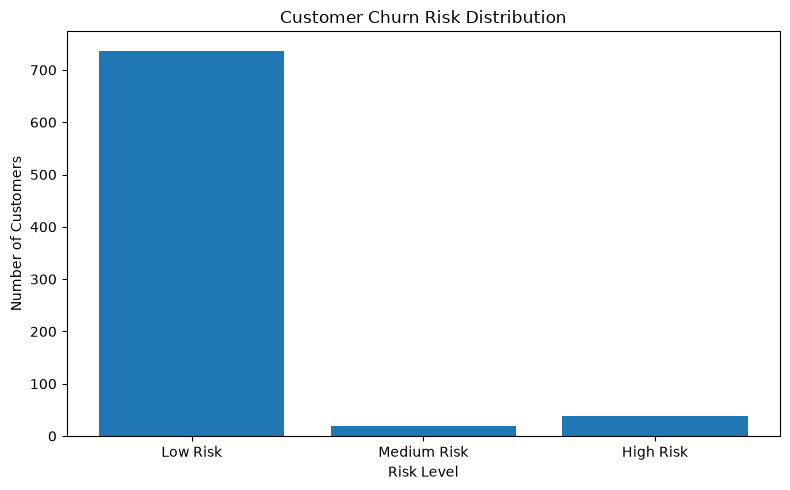

In [14]:
risk_counts = (
    risk_ranking["risk_level"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"], fill_value=0)
)

plt.figure(figsize=(8, 5))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

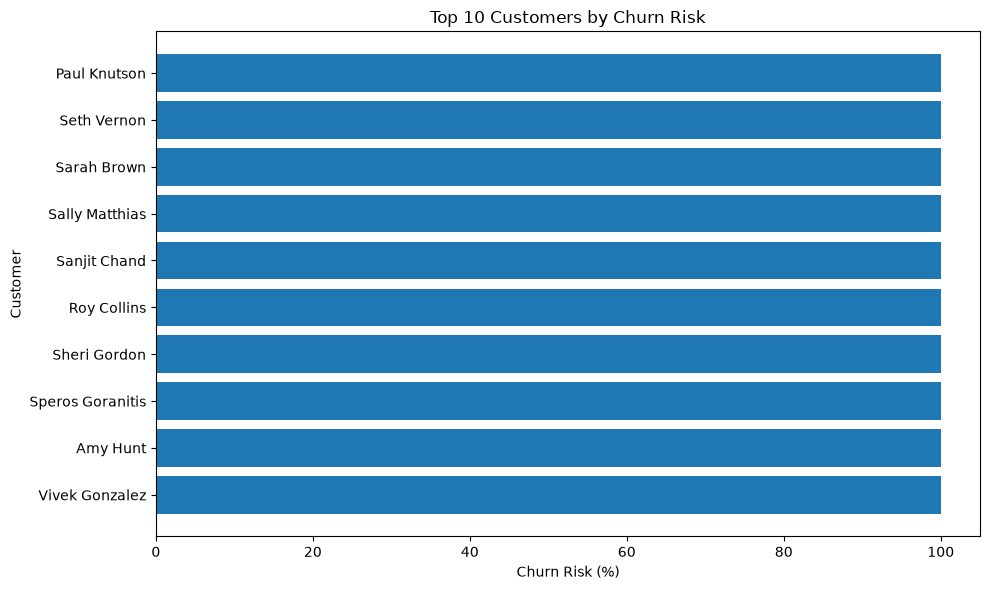

In [15]:
top_risk = risk_ranking.head(10).sort_values(
    "churn_probability"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_risk["customer_name"],
    top_risk["risk_percentage"]
)

plt.title("Top 10 Customers by Churn Risk")
plt.xlabel("Churn Risk (%)")
plt.ylabel("Customer")

plt.tight_layout()
plt.show()

In [16]:
def retention_strategy(risk_level):
    if risk_level == "High Risk":
        return "Personalized offer and priority customer follow-up"
    elif risk_level == "Medium Risk":
        return "Targeted discount and product recommendations"
    else:
        return "Regular engagement and loyalty rewards"

risk_ranking["retention_strategy"] = risk_ranking["risk_level"].apply(
    retention_strategy
)

print("Retention strategies assigned successfully!")

print(
    risk_ranking[
        [
            "customer_name",
            "risk_level",
            "risk_percentage",
            "retention_strategy"
        ]
    ].head(10)
)

Retention strategies assigned successfully!
      customer_name risk_level  risk_percentage  \
0    Vivek Gonzalez  High Risk            100.0   
1          Amy Hunt  High Risk            100.0   
2  Speros Goranitis  High Risk            100.0   
3      Sheri Gordon  High Risk            100.0   
4       Roy Collins  High Risk            100.0   
5      Sanjit Chand  High Risk            100.0   
6    Sally Matthias  High Risk            100.0   
7       Sarah Brown  High Risk            100.0   
8       Seth Vernon  High Risk            100.0   
9      Paul Knutson  High Risk            100.0   

                                  retention_strategy  
0  Personalized offer and priority customer follo...  
1  Personalized offer and priority customer follo...  
2  Personalized offer and priority customer follo...  
3  Personalized offer and priority customer follo...  
4  Personalized offer and priority customer follo...  
5  Personalized offer and priority customer follo...  
6  Person

In [17]:
risk_dashboard = risk_ranking[
    [
        "customer_name",
        "total_sales",
        "total_profit",
        "number_of_orders",
        "risk_percentage",
        "risk_level",
        "retention_strategy"
    ]
].copy()

risk_dashboard["risk_percentage"] = risk_dashboard[
    "risk_percentage"
].round(2)

print("Risk dashboard created successfully!")
print("Total customers:", len(risk_dashboard))

risk_dashboard.head(15)

Risk dashboard created successfully!
Total customers: 795


,customer_name,total_sales,total_profit,number_of_orders,risk_percentage,risk_level,retention_strategy
0,Vivek Gonzalez,10296.0,-364.42470,31,100.0,High Risk,Personalized offer and priority customer follo...
1,Amy Hunt,9202.0,718.33498,24,100.0,High Risk,Personalized offer and priority customer follo...
2,Speros Goranitis,12948.0,1541.10256,38,100.0,High Risk,Personalized offer and priority customer follo...
3,Sheri Gordon,13818.0,2338.98880,31,100.0,High Risk,Personalized offer and priority customer follo...
4,Roy Collins,7956.0,737.74570,26,100.0,High Risk,Personalized offer and priority customer follo...
5,Sanjit Chand,26524.0,8205.37990,35,100.0,High Risk,Personalized offer and priority customer follo...
6,Sally Matthias,13063.0,1528.36080,30,100.0,High Risk,Personalized offer and priority customer follo...
7,Sarah Brown,22300.0,1668.65412,38,100.0,High Risk,Personalized offer and priority customer follo...
8,Seth Vernon,23640.0,2222.75368,36,100.0,High Risk,Personalized offer and priority customer follo...
9,Paul Knutson,8232.0,-308.48944,20,100.0,High Risk,Personalized offer and priority customer follo...


In [18]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("Feature importance calculated successfully!")
print(feature_importance)

Feature importance calculated successfully!
                 feature  importance
2         total_quantity    0.183173
1           total_profit    0.178989
4       average_discount    0.166649
0            total_sales    0.165012
5  average_shipping_days    0.162308
3       number_of_orders    0.143869


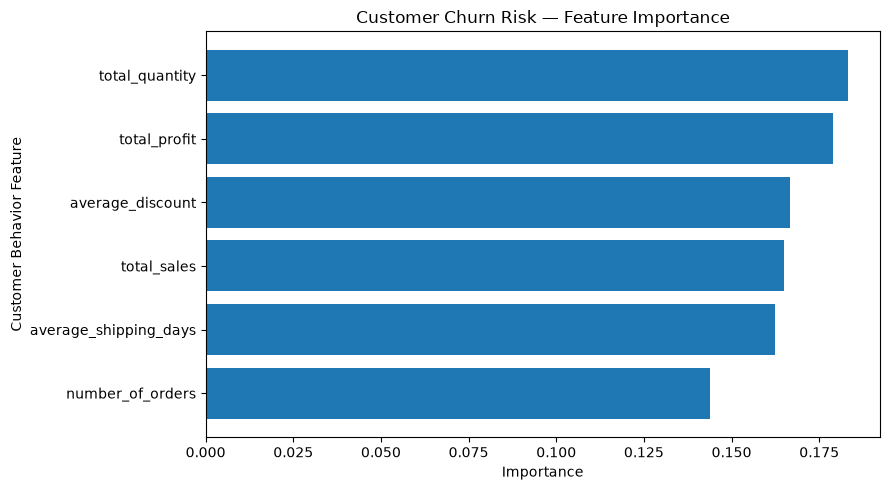

In [19]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.title("Customer Churn Risk — Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Customer Behavior Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [20]:
risk_dashboard.to_csv(
    "customer_risk_ranking.csv",
    index=False
)

feature_importance.to_csv(
    "risk_feature_importance.csv",
    index=False
)

print("Risk analysis files saved successfully!")
print("✓ customer_risk_ranking.csv")
print("✓ risk_feature_importance.csv")

Risk analysis files saved successfully!
✓ customer_risk_ranking.csv
✓ risk_feature_importance.csv


In [21]:
high_risk_count = (
    risk_dashboard["risk_level"] == "High Risk"
).sum()

medium_risk_count = (
    risk_dashboard["risk_level"] == "Medium Risk"
).sum()

low_risk_count = (
    risk_dashboard["risk_level"] == "Low Risk"
).sum()

average_risk = risk_dashboard["risk_percentage"].mean()

top_customer = risk_dashboard.iloc[0]["customer_name"]
top_customer_risk = risk_dashboard.iloc[0]["risk_percentage"]

report = f"""# Day 41 — Customer Churn Risk Analysis

## Objective

The objective of this analysis is to identify customers who may be at high risk of churn and recommend suitable retention strategies.

## Risk Summary

- Total customers analyzed: {len(risk_dashboard)}
- High-risk customers: {high_risk_count}
- Medium-risk customers: {medium_risk_count}
- Low-risk customers: {low_risk_count}
- Average predicted churn risk: {average_risk:.2f}%

## Highest-Risk Customer

The customer with the highest predicted churn risk is {top_customer}, with a predicted risk of {top_customer_risk:.2f}%.

## Retention Recommendations

### High-Risk Customers
Use personalized offers, priority follow-up, and targeted retention campaigns.

### Medium-Risk Customers
Use targeted discounts, product recommendations, and engagement campaigns.

### Low-Risk Customers
Maintain regular engagement and loyalty programs.

## Business Value

A predictive customer risk system can help businesses identify customers who may need attention before they become inactive. This allows retention teams to prioritize customers and use targeted strategies.

## Limitations

The model is based on historical customer behavior and simulated churn labels. The predictions should be treated as risk indicators rather than guaranteed churn outcomes.

Future improvements could include real customer churn labels, additional behavioral features, cohort-based retention analysis, and more advanced predictive models.
"""

with open(
    "business_recommendation_report.md",
    "w",
    encoding="utf-8"
) as file:
    file.write(report)

print("Business recommendation report created successfully!")

Business recommendation report created successfully!


In [22]:
import os

required_files = [
    "day41.ipynb",
    "customer_risk_ranking.csv",
    "risk_feature_importance.csv",
    "business_recommendation_report.md",
    "README.md"
]

print("Day 41 file check:\n")

for file in required_files:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗ Missing:", file)

Day 41 file check:

✓ day41.ipynb
✓ customer_risk_ranking.csv
✓ risk_feature_importance.csv
✓ business_recommendation_report.md
✓ README.md
